# S0-2 市場データ取得基盤（FRED・財務省・JSDA・BoE）

## 学習目標

- 国債の利回りデータの種類（パー利回り・ゼロレート・銘柄別利回り・価格）を
  区別し、ソースごとに何が手に入るかを説明できる
- API キーを `.env` から読み、取得結果をキャッシュするデータ層を理解する
- キーの無い環境でも動くよう、キャッシュ専用モードと合成サンプルへの
  フォールバックを使い分けられる
- 実データ（本 notebook では合成サンプル）で日米の10年金利スプレッドを
  計算し、欠損日の処理方針を決めて実装できる

## 実務での位置づけ（ファンドはどう稼ぐか）

市場データ取得基盤は、あらゆる債券戦略の入り口です。マーケットメイク・相対価値・キャリー・マクロ・ALM のどれをとっても、まず信頼できる利回りデータが無ければ何も始まりません。ここで学ぶ「パー利回り（年限グリッド）」と「銘柄別利回り」の区別は、収益源に直結します。財務省や FRED が出す年限グリッドのパー利回りはカーブ構築（S2）の入力になり、割引・評価・キーレートリスクの計算に使われます。一方、JSDA の売買参考統計値のような銘柄別利回りは、同じ10年ゾーンでも銘柄ごとにばらつき、この「ばらつき」こそが相対価値デスクの稼ぎ場です。フィット済みカーブから割安な銘柄を買い割高を売る rich/cheap 取引や、先物と現物の裁定（先物ベーシス・CTD）は、銘柄別データが無いと成立しません。

データ層をキャッシュ付き・再現可能に作ることは、実務では品質保証の問題です。ヘッジファンドの RV リサーチは過去データで戦略をバックテストして期待リターンとドローダウンを見積もり、リスク管理は日次で VaR やシナリオ損益を再計算します。同じ入力から同じ結果が返ることは、バックテストの信頼性とリスクレポートの監査可能性の前提であり、鍵の無い環境でもキャッシュや合成サンプルで動く構成は、CI や第三者検証をそのまま回せる設計です。秘密情報を `.env` からしか読まない作法も、実運用のオペレーショナルリスク管理の一部です。

欠損日の処理方針を明示的に決める点も実務的です。本文では前値埋め（`ffill`）を避けて観測のある日だけ使っていますが、休場日を実際の観測のように見せると、日米スプレッドの分布やボラティリティ推定が歪み、平均回帰戦略のシグナルや VaR の裾が過大・過小になります。データの前処理をどう倒すかが、最終的な取引判断とリスク量に効いてくる、という感覚をここで身につけます。


## 理論：利回りデータの種類とソースの違い

「10年金利」と一口に言っても、ソースによって中身が違う。混同するとカーブ
構築の入力を誤る。

| ソース | 手に入るもの | 粒度 | 本シリーズでの用途 |
|---|---|---|---|
| FRED（米セントルイス連銀） | UST の CMT 利回り、SOFR、実質金利、社債OAS指数 | 年限グリッド | 米カーブ・スプレッド分析 |
| 財務省 | JGB の利回り | 年限グリッド | 日本のカーブ構築 |
| JSDA（日本証券業協会） | 売買参考統計値（銘柄別の平均値単価・利回り） | 個別銘柄 | rich/cheap・先物ベーシス（S9） |
| Bank of England | 英国のノミナル/実質カーブ | 年限グリッド | 英カーブ・BEI |

押さえるべき区別は二つ。

- **パー利回り（グリッド）** は「その年限の標準的なクーポン債の利回り」で、
  年限ごとに1点。カーブ構築の入力になるが、そのまま割引に使うゼロレート
  ではない（剥ぎ取りが必要。S2）。
- **銘柄別利回り** は個別債券ごとの利回りで、同じ10年ゾーンでも銘柄によって
  ばらつく。この「ばらつき」こそが相対価値分析の対象になる（S9）。

財務省が公表するのは年限グリッドのパー利回りで、銘柄別の日次利回りは
JSDA の売買参考統計値が一次ソースになる。この2つは別物として扱う。

## スクラッチ実装：.env とキャッシュを備えたデータ層

`bondlab.data` に最小のデータアクセス層を実装してある。設計は3点。

1. 秘密情報（FRED API キー）は `.env` からのみ読む。コードや出力に書かない。
2. 取得結果は `data/cache/` に保存し、再実行で同じ結果を返す（再現性）。
3. 鍵の無い環境（CI・公開リポジトリの読者）では API を叩かず、キャッシュか
   合成サンプルで動く。

### 使用する自作関数

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `fred_series(series_id, cache_only=None)` | FRED系列ID, キャッシュ専用フラグ | `pd.Series` | FRED取得＋キャッシュ＋スキーマ検証 |
| `load_sample(name)` | サンプル名 | `pd.Series` | 合成/再配布可サンプルの読み込み（鍵不要） |

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import matplotlib.font_manager as _fm
for _f in ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Noto Sans JP", "TakaoPGothic", "IPAPGothic"]:
    if any(_f == _n.name for _n in _fm.fontManager.ttflist):
        plt.rcParams["font.family"] = _f
        break
plt.rcParams["axes.unicode_minus"] = False
from bondlab import data

# この notebook は鍵が無くても動くよう、既定では合成サンプルを使う。
# 実際の FRED を叩きたい場合は .env に FRED_API_KEY を入れて USE_LIVE=True にする。
USE_LIVE = bool(os.getenv("FRED_API_KEY")) and os.getenv("BONDLAB_DATA_MODE") != "cache_only"
print("USE_LIVE:", USE_LIVE, "（True なら実 FRED を取得、False なら合成サンプル）")

USE_LIVE: False （True なら実 FRED を取得、False なら合成サンプル）


### 実データ取得パス（鍵がある場合のみ）

鍵があるときは FRED から DGS10（UST 10年 CMT）を取得する。無いときはこの
セルはスキップし、次の合成サンプルへ進む。取得したデータは自動でキャッシュ
され、次回以降はネットワーク無しで同じ結果を返す。

In [2]:
if USE_LIVE:
    us10 = data.fred_series("DGS10")   # 単位: パーセント
    jp_available = False               # JGB は財務省/JSDA 側。S2 で追加する
    print("FRED DGS10 を取得:", us10.index.min().date(), "〜", us10.index.max().date())
else:
    print("鍵が無いため実取得はスキップし、合成サンプルを使う")

鍵が無いため実取得はスキップし、合成サンプルを使う


### 合成サンプルパス（鍵が無くても動く）

教材用に、現実的な水準・変動を持つ合成の10年利回り（日米）を
`data/samples/` に用意してある。これは本物の市場データではなく、
`scripts/make_sample_yields.py` が決定論的に生成したもの。

In [3]:
us10 = data.load_sample("synthetic_us10y")   # 合成 US 10Y（単位: パーセント）
jp10 = data.load_sample("synthetic_jp10y")   # 合成 JP 10Y

print("US10Y 合成:", us10.index.min().date(), "〜", us10.index.max().date(), "件数", len(us10))
print("JP10Y 合成:", jp10.index.min().date(), "〜", jp10.index.max().date(), "件数", len(jp10))
print("\n先頭:")
display(us10.head(3))

US10Y 合成: 2000-01-03 〜 2025-12-31 件数 6783
JP10Y 合成: 2000-01-03 〜 2025-12-31 件数 6783

先頭:


date
2000-01-03    6.50
2000-01-04    6.51
2000-01-05    6.54
Name: synthetic_us10y, dtype: float64

## 実データ適用：日米10年スプレッドと欠損処理

2つの系列は営業日カレンダーが異なり、欠損日も混じる。スプレッドを取る前に
「どう揃えるか」を決める。ここでは次の方針を採る。

- 両系列を日付で内部結合（両方に値がある日だけ残す）
- 残った欠損は前値埋め（`ffill`）せず、その日を除外する

前値埋めは連続した休場を実際の観測のように見せてしまうため、スプレッドの
分布を歪める。分析用途では「観測がある日だけ使う」方が安全に倒せる。

**数値例**：合成サンプル最終日（2025-12-31）は US10Y $= 3.56\%$、JP10Y $= 1.32\%$ なので、日米スプレッドは $(3.56 - 1.32) \times 100 = 224\ \text{bp}$ です。パーセント差を100倍して bp（ベーシスポイント）に換算しています。


In [4]:
df = pd.concat({"US10Y": us10, "JP10Y": jp10}, axis=1)
print("結合直後の欠損数:")
display(df.isna().sum())

# 両方に値がある日だけ残す。
df = df.dropna(how="any")
df["spread_bp"] = (df["US10Y"] - df["JP10Y"]) * 100.0   # パーセント差を bp へ
print("\n欠損除外後の期間:", df.index.min().date(), "〜", df.index.max().date(), "件数", len(df))
display(df[["US10Y", "JP10Y", "spread_bp"]].tail(3))

結合直後の欠損数:


US10Y    13
JP10Y    13
dtype: int64


欠損除外後の期間: 2000-01-03 〜 2025-12-31 件数 6757


,US10Y,JP10Y,spread_bp
date,,,
2025-12-29,3.61,1.33,228.0
2025-12-30,3.60,1.34,226.0
2025-12-31,3.56,1.32,224.0


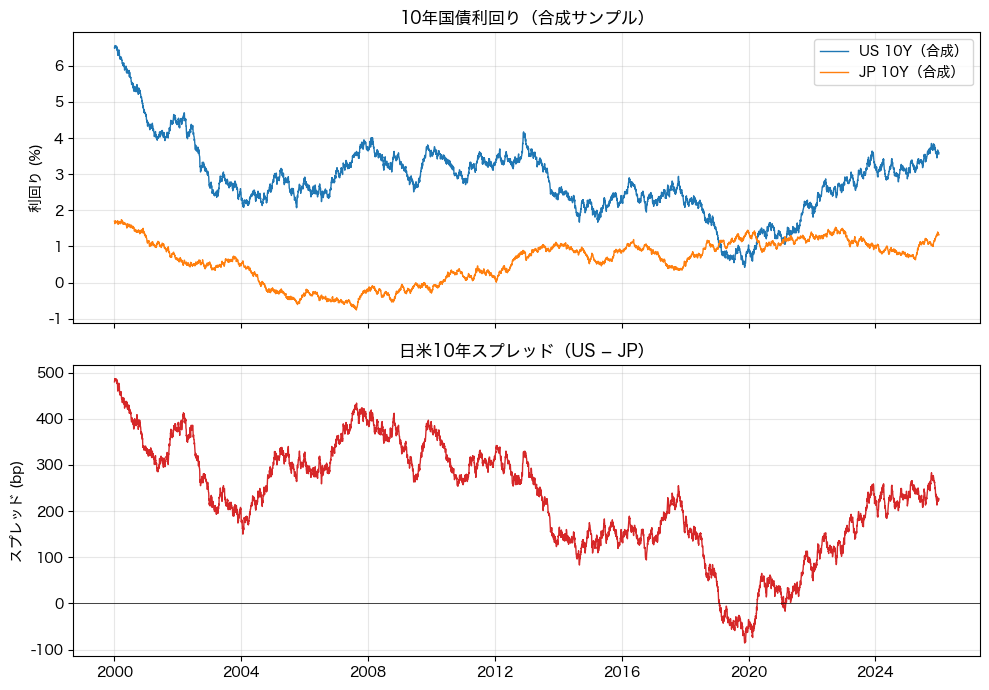

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

ax1.plot(df.index, df["US10Y"], label="US 10Y（合成）", lw=1.0)
ax1.plot(df.index, df["JP10Y"], label="JP 10Y（合成）", lw=1.0)
ax1.set_ylabel("利回り (%)")
ax1.set_title("10年国債利回り（合成サンプル）")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(df.index, df["spread_bp"], color="tab:red", lw=1.0)
ax2.axhline(0, color="k", lw=0.5)
ax2.set_ylabel("スプレッド (bp)")
ax2.set_title("日米10年スプレッド（US − JP）")
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

合成データなので水準そのものに意味はない。ここで確認したいのは、
2系列を営業日カレンダーの違いを吸収して揃え、スプレッド系列を再現可能に
作れることと、欠損処理の方針が結果に効くことである。

## 演習

1. 欠損処理の方針を「前値埋め（`ffill`）」に変えてスプレッドを作り直し、
   除外方式との差を分布（ヒストグラム）で比較せよ。前値埋めが分布の裾に
   与える影響を一言で述べよ。
2. `bondlab.data.fred_series` に `cache_only=True` を渡したとき、キャッシュ
   が無ければ `RuntimeError` が出ることを確認せよ。次に、鍵のある環境で
   一度 `DGS10` を取得してキャッシュを作り、以降 `cache_only=True` で同じ
   データが返ることを確かめよ（CI がこの仕組みで動く）。
3. スプレッドの水準が大きく動いた月を上位5つ抽出し、月次のボラティリティ
   （日次変化の標準偏差）を計算して表にせよ。

解答例は `solutions/S0/` に置く。

## 用語集

定義の正は `glossary/00_tooling.md`。初出語の一行要約のみ示す。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| [パー利回り](../../glossary/00_tooling.md#par-yield) | par yield | その年限の標準クーポン債が額面で取引される利回り。カーブ構築の入力 |
| [CMT](../../glossary/00_tooling.md#constant-maturity-treasury) | constant maturity treasury | 一定年限に補間した米国債利回り。FRED の DGS 系列 |
| [売買参考統計値](../../glossary/00_tooling.md#jsda-reference-prices) | JSDA reference prices | JSDA が公表する銘柄別の平均値単価・利回り |
| [ベンチマーク銘柄](../../glossary/00_tooling.md#benchmark-issue) | benchmark issue | 各年限の代表銘柄。直近発行の流動性が高い銘柄が多い |
| [API キー](../../glossary/00_tooling.md#api-key) | API key | 外部サービス認証用の秘密情報。`.env` で管理しコードに書かない |